# 03 — Fraud Detection Modeling
**Goal:** Melatih dan mengevaluasi classifier untuk deteksi fraud.
**Dataset:** `transactions_featured.csv` (26,772 rows, fraud rate 17.31%)
**Models:** Random Forest, XGBoost
**Handling imbalance:** class_weight + SMOTE comparison

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
REPORTS_DIR   = Path('..') / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

## 1. Load & Persiapkan Data

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'transactions_featured.csv')
print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["is_fraud"].mean()*100:.2f}%')
df.head(3)

Shape: (26772, 38)
Fraud rate: 17.31%


,dpt_id,dpt_promotion_id,buyer_id,seller_id,transaction_amount,payment_method_name,payment_provider_name,transaction_created_datetime,transaction_updated_datetime,is_outlier_iqr,...,seller_user_fraud_flag,buyer_blacklist_account_flag,seller_blacklist_account_flag,buyer_company_kyc_status_name,seller_company_kyc_status_name,buyer_company_kyb_status_name,seller_company_kyb_status_name,buyer_company_age_days,seller_company_age_days,is_fraud
0,d8c359cc9de4f730939cfa6c5b50bac2215cf994a30816...,No Promotion,001046b5061e28476b83fe2335b04d3210bed72a2fee17...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,200000771.0,BANK_TRANSFER,BCA_MANUAL,2023-08-13 11:50:37.122442,2023-08-13 13:04:54.522228,1,...,0.0,0,0.0,VALIDASI_BERHASIL,BELUM_VALIDASI,BELUM_VALIDASI,BELUM_VALIDASI,1061,1858.0,0
1,769c7fdcc0e36175c9363c6d822ebb5b9c8748acb8c12e...,No Promotion,001046b5061e28476b83fe2335b04d3210bed72a2fee17...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,300000000.0,BANK_TRANSFER,BRI,2023-12-29 19:10:25.077279,2023-12-29 19:29:08.463497,1,...,0.0,0,0.0,VALIDASI_BERHASIL,BELUM_VALIDASI,BELUM_VALIDASI,BELUM_VALIDASI,1061,1858.0,0
2,d808c4f7daf19127c77a79dffadf947d9a5d4fa4a9ecb7...,No Promotion,00119737eef11ff1d30c2061dd1e19c06d963d5a125c92...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,20290000.0,CREDIT_CARD,MASTERCARD,2023-05-05 10:12:38.083254,2023-05-31 09:19:27.323998,0,...,0.0,0,0.0,VALIDASI_BERHASIL,BELUM_VALIDASI,VALIDASI_BERHASIL,BELUM_VALIDASI,1164,1858.0,0


In [3]:
# Pilih fitur numerik untuk model
# FIX: hapus is_self_transaction — data leakage (69.7% importance tidak wajar)
FEATURE_COLS = [
    'transaction_amount',
    'transaction_amount_scaled',
    'is_outlier_iqr',
    'anomaly',
    'transaction_count',
    'relationship_score_z',
    'relationship_anomaly',
    'time_diff_minutes',
    'time_diff_minutes_zscore',
    'is_burst',
    'burst_intensity',
    'is_unusual_gap',
    'promo_usage_count_buyer',
    'promo_usage_count_seller',
    'promo_exploit_buyer',
    'promo_exploit_seller',
    'buyer_company_age_days',
    'seller_company_age_days',
]

# Hanya pakai kolom yang ada
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET       = 'is_fraud'

X = df[FEATURE_COLS].fillna(0)
y = df[TARGET]

print(f'Features  : {len(FEATURE_COLS)}')
print(f'X shape   : {X.shape}')
print(f'Class dist: {y.value_counts().to_dict()}')


Features  : 18
X shape   : (26772, 18)
Class dist: {0: 22139, 1: 4633}


In [4]:
# Stratified split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  : {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train : (21417, 18) | Fraud: 3706 (17.3%)
Test  : (5355, 18)  | Fraud: 927 (17.3%)


## 2. Baseline: Random Forest (class_weight)

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_rf):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92      4428
       Fraud       0.61      0.71      0.66       927

    accuracy                           0.87      5355
   macro avg       0.78      0.81      0.79      5355
weighted avg       0.88      0.87      0.88      5355

ROC-AUC : 0.8927
PR-AUC  : 0.7751


## 3. XGBoost (scale_pos_weight)

In [6]:
neg, pos     = (y_train == 0).sum(), (y_train == 1).sum()
scale_weight = neg / pos
print(f'scale_pos_weight: {scale_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_xgb):.4f}')

scale_pos_weight: 4.78
=== XGBoost ===
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.96      4428
       Fraud       0.77      0.83      0.80       927

    accuracy                           0.93      5355
   macro avg       0.87      0.89      0.88      5355
weighted avg       0.93      0.93      0.93      5355

ROC-AUC : 0.9543
PR-AUC  : 0.8982


## 4. XGBoost + SMOTE

In [7]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Sebelum SMOTE: {dict(y_train.value_counts())}')
print(f'Setelah SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_smote.fit(X_train_sm, y_train_sm)

y_pred_xgb_sm  = xgb_smote.predict(X_test)
y_proba_xgb_sm = xgb_smote.predict_proba(X_test)[:, 1]

print('\n=== XGBoost + SMOTE ===')
print(classification_report(y_test, y_pred_xgb_sm, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb_sm):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_xgb_sm):.4f}')

Sebelum SMOTE: {0: np.int64(17711), 1: np.int64(3706)}
Setelah SMOTE: {0: np.int64(17711), 1: np.int64(17711)}

=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

      Normal       0.93      0.96      0.95      4428
       Fraud       0.77      0.67      0.72       927

    accuracy                           0.91      5355
   macro avg       0.85      0.82      0.83      5355
weighted avg       0.91      0.91      0.91      5355

ROC-AUC : 0.9020
PR-AUC  : 0.8091


## 5. Perbandingan Model

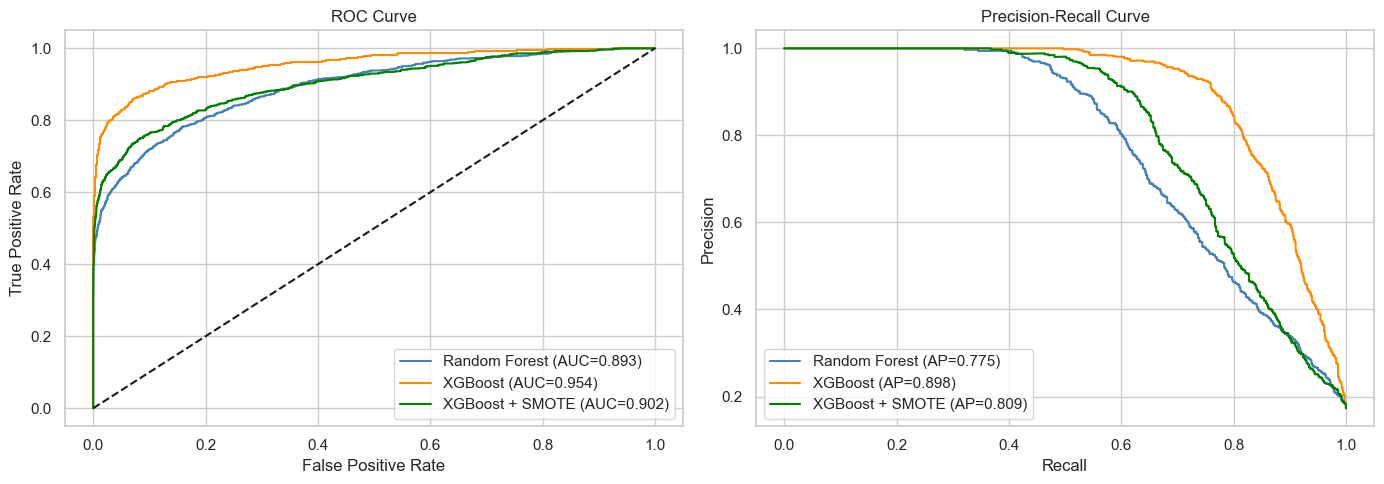

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Random Forest'   : (y_proba_rf,     'steelblue'),
    'XGBoost'         : (y_proba_xgb,    'darkorange'),
    'XGBoost + SMOTE' : (y_proba_xgb_sm, 'green'),
}

# ROC Curve
for name, (proba, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
for name, (proba, color) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_model_comparison.png', dpi=150)
plt.show()

## 6. Confusion Matrix — Best Model

Best model: XGBoost (PR-AUC=0.8982)


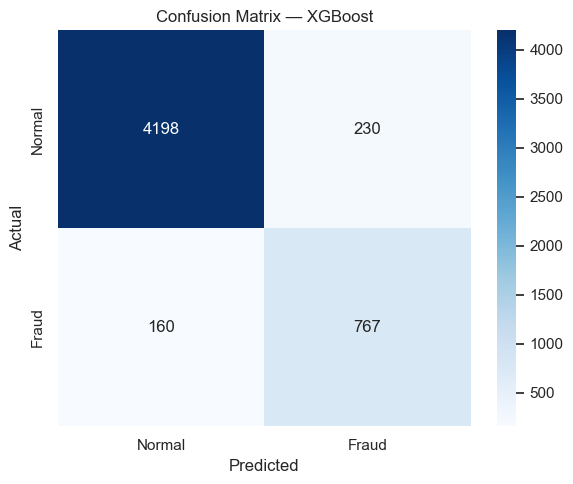

In [9]:
# Pilih model terbaik berdasarkan PR-AUC (lebih relevan untuk imbalanced)
scores = {
    'Random Forest'   : average_precision_score(y_test, y_proba_rf),
    'XGBoost'         : average_precision_score(y_test, y_proba_xgb),
    'XGBoost + SMOTE' : average_precision_score(y_test, y_proba_xgb_sm),
}
best_name  = max(scores, key=scores.get)
best_pred  = {'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb, 'XGBoost + SMOTE': y_pred_xgb_sm}[best_name]
best_proba = {'Random Forest': y_proba_rf, 'XGBoost': y_proba_xgb, 'XGBoost + SMOTE': y_proba_xgb_sm}[best_name]

print(f'Best model: {best_name} (PR-AUC={scores[best_name]:.4f})')

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_confusion_matrix.png', dpi=150)
plt.show()

## 7. Feature Importance

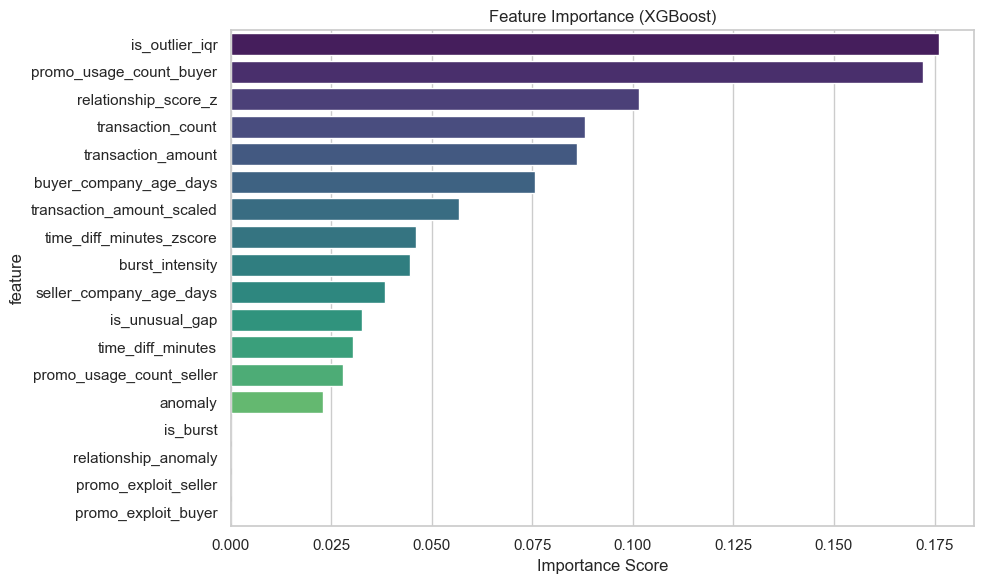

                  feature  importance
           is_outlier_iqr    0.176012
  promo_usage_count_buyer    0.172130
     relationship_score_z    0.101651
        transaction_count    0.088230
       transaction_amount    0.086065
   buyer_company_age_days    0.075799
transaction_amount_scaled    0.056797
 time_diff_minutes_zscore    0.046160
          burst_intensity    0.044582
  seller_company_age_days    0.038407
           is_unusual_gap    0.032615
        time_diff_minutes    0.030505
 promo_usage_count_seller    0.028060
                  anomaly    0.022987
                 is_burst    0.000000
     relationship_anomaly    0.000000
     promo_exploit_seller    0.000000
      promo_exploit_buyer    0.000000


In [10]:
# Gunakan XGBoost untuk feature importance
best_xgb = xgb if scores['XGBoost'] >= scores['XGBoost + SMOTE'] else xgb_smote

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

# Prediksi seluruh dataset dengan best model

In [11]:
# Prediksi seluruh dataset dengan best model
best_model = {'Random Forest': rf, 'XGBoost': xgb, 'XGBoost + SMOTE': xgb_smote}[best_name]

df_export = df[FEATURE_COLS + ['dpt_id', 'buyer_id', 'seller_id',
                                'transaction_amount', 'transaction_created_datetime',
                                'is_fraud']].copy()
df_export.fillna(0, inplace=True)

df_export['fraud_probability'] = best_model.predict_proba(df[FEATURE_COLS].fillna(0))[:, 1]
df_export['fraud_predicted']   = best_model.predict(df[FEATURE_COLS].fillna(0))
df_export['risk_level']        = pd.cut(
    df_export['fraud_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

df_export.to_csv(PROCESSED_DIR / 'fraud_predictions.csv', index=False)

print('Export: fraud_predictions.csv')
print(f'Shape  : {df_export.shape}')
print(f'\nRisk level distribution:')
print(df_export['risk_level'].value_counts())

Export: fraud_predictions.csv
Shape  : (26772, 27)

Risk level distribution:
risk_level
Low       18795
High       4341
Medium     3636
Name: count, dtype: int64


## 9. Summary Hasil Modeling

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

print('=' * 55)
print(f'{"MODEL":<25} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>6} {"Recall":>8}')
print('-' * 55)

for name, proba, pred in [
    ('Random Forest',    y_proba_rf,     y_pred_rf),
    ('XGBoost',          y_proba_xgb,    y_pred_xgb),
    ('XGBoost + SMOTE',  y_proba_xgb_sm, y_pred_xgb_sm),
]:
    roc  = roc_auc_score(y_test, proba)
    pr   = average_precision_score(y_test, proba)
    f1   = f1_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    mark = ' ← best' if name == best_name else ''
    print(f'{name:<25} {roc:>8.4f} {pr:>8.4f} {f1:>6.4f} {rec:>8.4f}{mark}')

print('=' * 55)

MODEL                      ROC-AUC   PR-AUC     F1   Recall
-------------------------------------------------------
Random Forest               0.8927   0.7751 0.6593   0.7109
XGBoost                     0.9543   0.8982 0.7973   0.8274 ← best
XGBoost + SMOTE             0.9020   0.8091 0.7192   0.6742
